In [10]:
import pandas as pd

In [11]:
#To load the dataset
df = pd.read_csv("1) iris.csv")
print(df.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


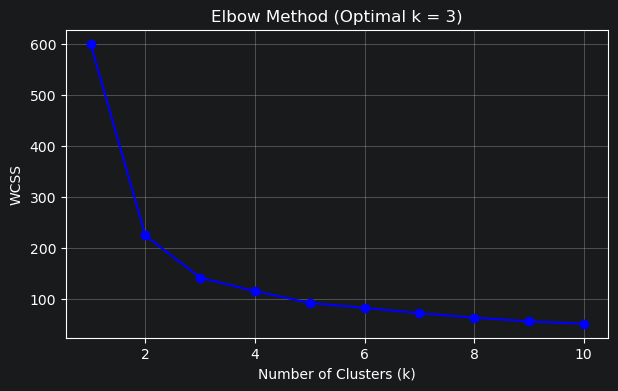

In [12]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Scale data
X = df.drop(columns=['species'], errors='ignore')
X_scaled = StandardScaler().fit_transform(X)

# 2. Elbow Method
wcss = [
    KMeans(n_clusters=k, random_state=42, n_init=10)
    .fit(X_scaled)
    .inertia_
    for k in range(1, 11)
]

# 3. Plot
plt.figure(figsize=(7, 4))
plt.plot(range(1, 11), wcss, 'bo-')
plt.title('Elbow Method (Optimal k = 3)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.grid(True)
plt.savefig("elbow_method.png")
plt.show()

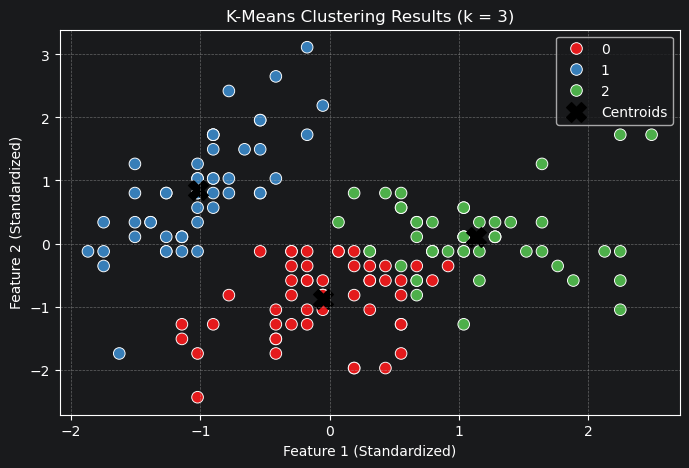

In [13]:
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# 1. Fit K-Means with optimal k = 3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# 2. 2D Scatter Plot of Clusters
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x=X_scaled[:, 0],
    y=X_scaled[:, 1],
    hue=df['Cluster'],
    palette='Set1',
    s=70,
)

# Plot cluster centroids
centroids = kmeans.cluster_centers_
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    c='black',
    s=200,
    marker='X',
    label='Centroids',
)

plt.title('K-Means Clustering Results (k = 3)')
plt.xlabel('Feature 1 (Standardized)')
plt.ylabel('Feature 2 (Standardized)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig("clustering_analysis.png")
plt.show()